# This Notebook given an example on how to highlight within the main olfactory epithelium and olfactory bulb the OSNs responding to different ethologically relevant cues. (Figure 7 in the manuscript)

### Load the functional and spatial data 

In [1]:
import pickle
import matplotlib.pylab as plt
dropbox_fld = r'C:\Users\Bogdan\Dropbox\ToMathematicaOR2021'
dics = pickle.load(open(dropbox_fld+r'\dic_frs_final-paper_V1.pkl','rb'))
dic_fr_female_to_male,dic_fr_male_to_male,dic_fr_male_to_female,dic_fr_female_to_female,dic_fr_cat,dic_fr_acetold = dics
dic_fr_virg,dic_fr_mom = pickle.load(open(dropbox_fld+r'\dic_frs_virg_mom.pkl','rb'))
res = pickle.load(open(dropbox_fld+r'\dic_scRNA-seq__mean_expr_f_VNEW.pkl','rb'))
expr = res[0]
genes = res[1]
OsE = res[2]

#import umap
import pickle
import numpy as np
import matplotlib.pylab as plt
from matplotlib import cm
import os,glob
from scipy.spatial.distance import cdist
from mpl_toolkits import mplot3d

dropbox_save_fld = r'C:\Users\Bogdan\Dropbox\ToMathematicaOR2021'
X_tot = np.load(dropbox_save_fld+r'\X_tot.npy')
olfr_tot = np.load(dropbox_save_fld+r'\olfr_tot.npy')
is_med_tot = np.load(dropbox_save_fld+r'\is_med_tot.npy')
XSurf__ = np.load(dropbox_save_fld+r'\pointsSurface_final.npy')
X_MOE,O_MOE,XSurf__MOE = pickle.load(open(dropbox_save_fld+r'\X_MOE--O_MOE--XSurf__MOE.pkl','rb'))
is_med_XSurf = is_med_tot[np.argmin(cdist(XSurf__,X_tot),-1)]

### Example for cat odor

In [2]:
dic = dic_fr_cat
th=0.15 ### setup a threshold for the reponse
import napari
V=napari.Viewer(ndisplay=3)
col = (np.array([(dic.get(o,0)>th)*(dic.get(o,0)) for o in olfr_tot]))*350
V.add_points(XSurf__,size=60,face_color=[0.3]*3,edge_width=0)
keep = (is_med_tot==1)&(col>0)
V.add_points(X_tot[keep],size=col[keep],face_color=[0,1,0],edge_width=0,blending='Additive')
keep = (is_med_tot==0)&(col>0)
V.add_points(X_tot[keep],size=col[keep],face_color=[0,1,0],edge_width=0,blending='Additive')

#V.camera.center,V.camera.zoom,V.camera.angles = [(-3377.5, 2327.5, 1435.0), 0.26, (173.5224277595916, -21.307405172466016, -39.86817140388365)]

<Points layer 'Points [1]' at 0x21413ddaaf0>

([], [])

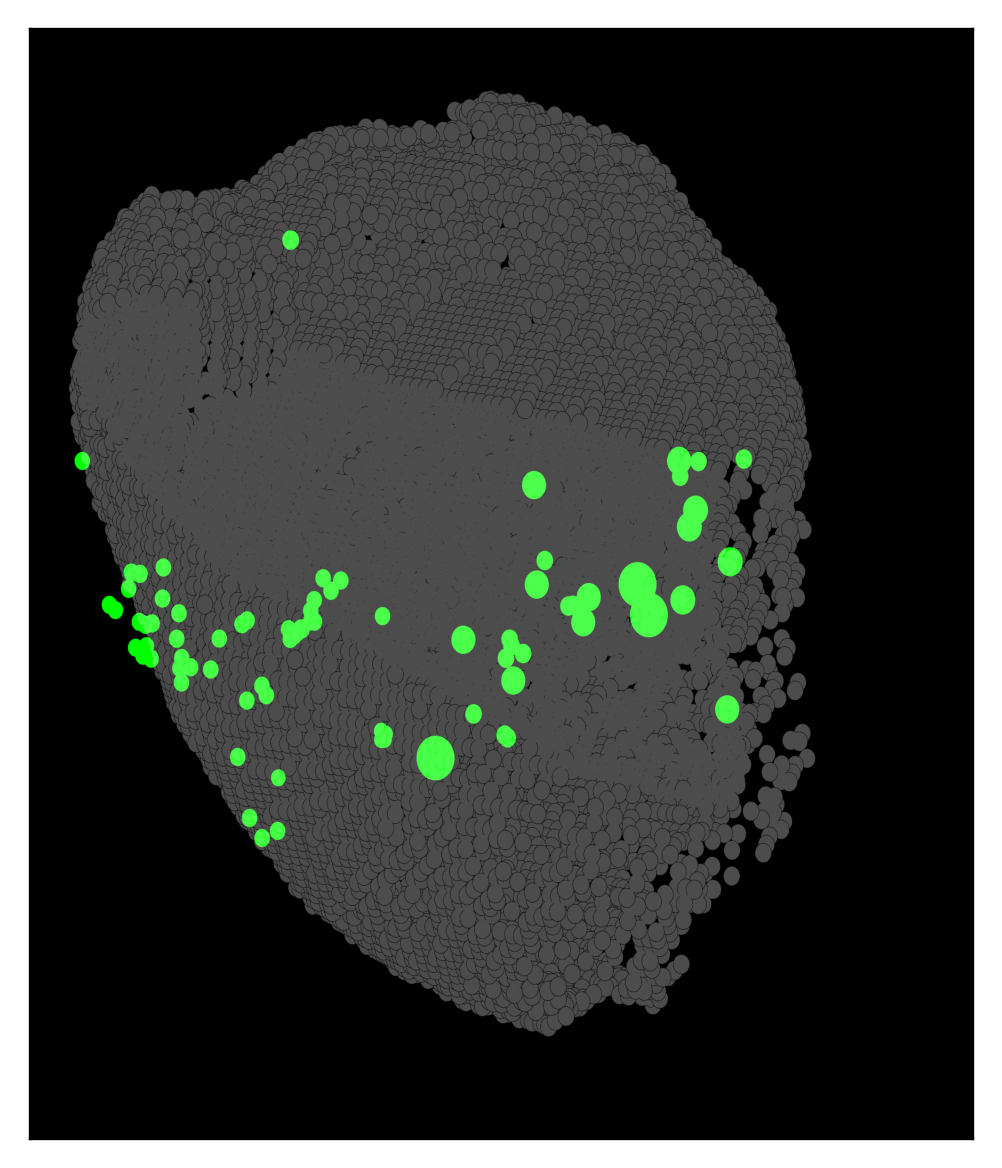

In [3]:
V.camera.center,V.camera.zoom,V.camera.angles = [(-3377.5, 2327.5, 1435.0), 0.38, (173.5224277595916, -21.307405172466016, -39.86817140388365)]
im = V.screenshot(size=(3000,3000))
fig = plt.figure(dpi=300)
plt.imshow(im,extent = [0,im.shape[0]*0.85,0,im.shape[1]])
plt.xticks([])
plt.yticks([])
#plt.
#fig.savefig(r"C:\Users\Bogdan\Dropbox\ORFigures\Figures2024\BaseImages_2024\Figure7\cat_OB_alone.png")

In [5]:
dic_colors = {'cat':[0,1,0],'male_to_female':[1,0.,0],'male_to_male':[1,1,0],'female_to_male':[0.,0.25,1],'female_to_female':[0,1,1],'mom':[1,0,1],'virgin':[1,1,1]}

([], [])

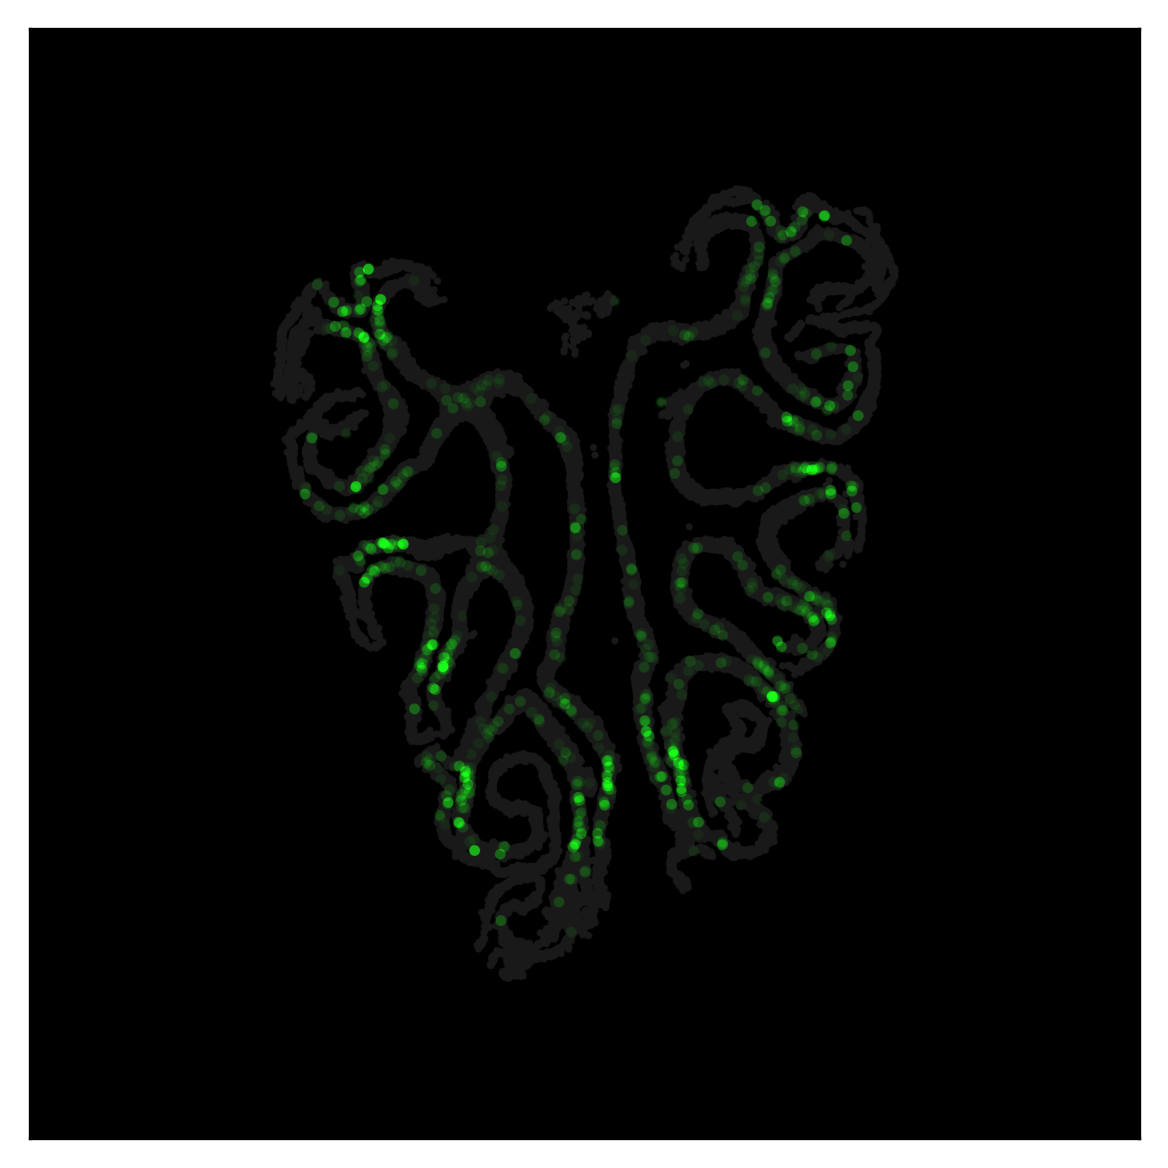

In [6]:
V = napari.view_points(X_MOE*[-1,1],face_color =[0.1]*3,size=50,edge_width=0)
dic = dic_fr_cat

col = np.array([list(dic_colors['cat'])+[(dic.get(o,0)>0.15)*(dic.get(o,0)-0.1)] if o in dic else [0,0,0,0] for o in O_MOE])
keep = col[:,-1]>0
#col = np.array([list(dic_colors['male_to_male'])+[(dic.get(o,0)>0.15)*(dic.get(o,0)-0.1)] if o in dic else [0,0,0,0] for o in O_MOE])
V.add_points(X_MOE[keep]*[-1,1],face_color=col[keep],edge_width=0,size=75,blending='Additive')

im = V.screenshot(size=(3000,3000))
fig = plt.figure(dpi=300)
plt.imshow(im)#,extent = [0,im.shape[0]*0.85,0,im.shape[1]])
plt.xticks([])
plt.yticks([])
#fig.savefig(r"C:\Users\Bogdan\Dropbox\ORFigures\Figures2024\BaseImages_2024\Figure7\MOE_cat.png")

### Quantify the density of responding OSN projections across AP and DV axis of the olfatory bulb

In [10]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
#dic= dic_fr_female_to_male
#dic= dic_fr_male_to_male
#dic= dic_fr_female_to_female
len(X_tot),len(olfr_tot)
AP_axis = -np.array([ 0.59239442, -0.38334092,  0.70860133])
DV_axis = -np.array([-0.80564726, -0.28119515,  0.52140367])

def get_signal_axis(ax_,med_=1):
    dir_ = np.dot(X_tot,ax_)
    max_,min_ = np.percentile(dir_,98),np.percentile(dir_,2)
    res = 30
    dintegrate = 200
    planes = np.arange(min_+dintegrate/2,max_-dintegrate/2,res)
    mean_expr = []
    for pl in planes:
        keep = (np.abs(dir_-pl)<dintegrate)&(is_med_tot==med_)
        mean_expr.append(np.nanmean([dic.get(o,np.nan)>0.1 for o in olfr_tot[keep]]))
    return planes,mean_expr

Text(0.5, 0, 'Anterior-posterior position (um)')

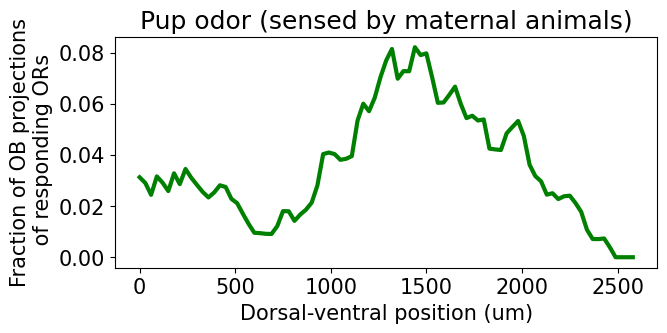

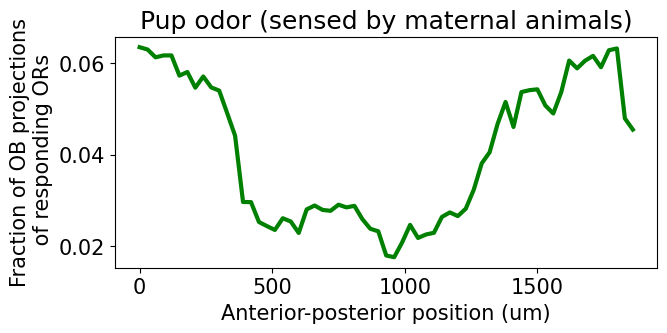

In [11]:

plt.figure(figsize=(7,3))
dic= dic_fr_cat
name = "Pup odor (sensed by maternal animals)"
col = 'green'#np.array([1,0,0])#*0.75

#plt.plot(get_signal_axis(AP_axis))
x,y = get_signal_axis(DV_axis)
x = x-np.min(x)
plt.plot(x,y,lw=3,color=col)
plt.title(name)
plt.ylabel("Fraction of OB projections\n of responding ORs")
plt.xlabel("Dorsal-ventral position (um)")


plt.figure(figsize=(7,3))
x,y = get_signal_axis(AP_axis)
x = x-np.min(x)
plt.plot(x,y,lw=3,color=col)
plt.title(name)
plt.ylabel("Fraction of OB projections\n of responding ORs")
plt.xlabel("Anterior-posterior position (um)")